In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
n=int(input("Enter the number of data points:"))
m=int(input("Enter the degree of polynomial regression:"))
m=m+1
x=[]
y=[]
for i in range(n):
    xi=float(input(f"Enter x[{i+1}]: "))
    yi=float(input(f"Enter y[{i+1}]: "))
    x.append(xi)
    y.append(yi)
df=pd.DataFrame({
    "x":x,
    "y":y
    })
df


,x,y
0,-5.0,-268.00
1,-4.5,-171.83
2,-4.0,-97.54
3,-3.5,-44.16
4,-3.0,-8.92
5,-2.5,13.47
6,-2.0,26.88
7,-1.5,34.71
8,-1.0,41.02
9,-0.5,46.91


In [124]:
X=np.zeros((n,m),dtype=float)
for i in range(n):
  for j in range(m):
    X[i][j]=x[i]**(j)

print(X)  
   

[[ 1.00000000e+00 -5.00000000e+00  2.50000000e+01 -1.25000000e+02
   6.25000000e+02 -3.12500000e+03  1.56250000e+04 -7.81250000e+04]
 [ 1.00000000e+00 -4.50000000e+00  2.02500000e+01 -9.11250000e+01
   4.10062500e+02 -1.84528125e+03  8.30376562e+03 -3.73669453e+04]
 [ 1.00000000e+00 -4.00000000e+00  1.60000000e+01 -6.40000000e+01
   2.56000000e+02 -1.02400000e+03  4.09600000e+03 -1.63840000e+04]
 [ 1.00000000e+00 -3.50000000e+00  1.22500000e+01 -4.28750000e+01
   1.50062500e+02 -5.25218750e+02  1.83826562e+03 -6.43392969e+03]
 [ 1.00000000e+00 -3.00000000e+00  9.00000000e+00 -2.70000000e+01
   8.10000000e+01 -2.43000000e+02  7.29000000e+02 -2.18700000e+03]
 [ 1.00000000e+00 -2.50000000e+00  6.25000000e+00 -1.56250000e+01
   3.90625000e+01 -9.76562500e+01  2.44140625e+02 -6.10351562e+02]
 [ 1.00000000e+00 -2.00000000e+00  4.00000000e+00 -8.00000000e+00
   1.60000000e+01 -3.20000000e+01  6.40000000e+01 -1.28000000e+02]
 [ 1.00000000e+00 -1.50000000e+00  2.25000000e+00 -3.37500000e+00
   

In [125]:
Y=np.array(df['y']).reshape(n,1)
print(Y)

[[-268.  ]
 [-171.83]
 [ -97.54]
 [ -44.16]
 [  -8.92]
 [  13.47]
 [  26.88]
 [  34.71]
 [  41.02]
 [  46.91]
 [  50.02]
 [  48.83]
 [  43.76]
 [  33.42]
 [  16.31]
 [ -10.57]
 [ -50.18]
 [-105.64]
 [-180.22]
 [-277.34]
 [-400.87]]


In [126]:
XT=X.T
XTX=np.dot(XT, X)
XTX_inv=np.linalg.inv(XTX)
XTy=np.dot(XT, Y)
a= np.dot(XTX_inv, XTy)
print(f"Co-efficients are:\n{a}")


Co-efficients are:
[[ 4.82979325e+01]
 [ 2.64316093e+00]
 [-4.73186107e+00]
 [-1.52868730e+00]
 [-4.54774731e-01]
 [ 6.10957445e-02]
 [ 1.24201393e-03]
 [-1.01769074e-03]]


In [127]:
Y_pred=np.array([])
for i in range(n):
    Y_pred=np.append(Y_pred, sum(a[j]*x[i]**j for j in range(m)))
Y_pred.shape    

(21,)

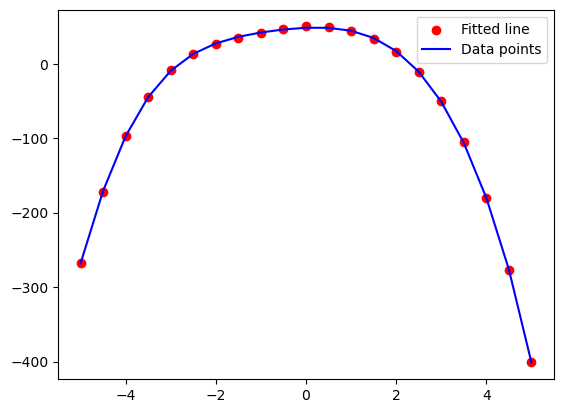

In [128]:
plt.scatter(x,y,color='red')
plt.plot(x, Y_pred,color='blue')
plt.legend(["Fitted line","Data points"])



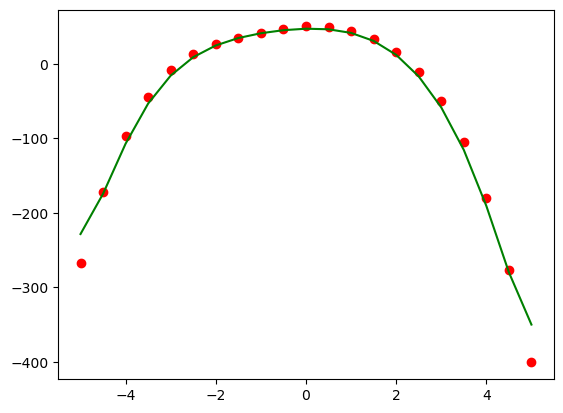

In [129]:
from scipy.ndimage import gaussian_filter1d
y_smooth=gaussian_filter1d(Y_pred,sigma=1)
plt.plot(x,y_smooth,color='green')
plt.scatter(x,y,color='red')